In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

Today's date: 2026-05-26
75 [256, 128, 64] 4 [0.3, 0.3, 0.3]


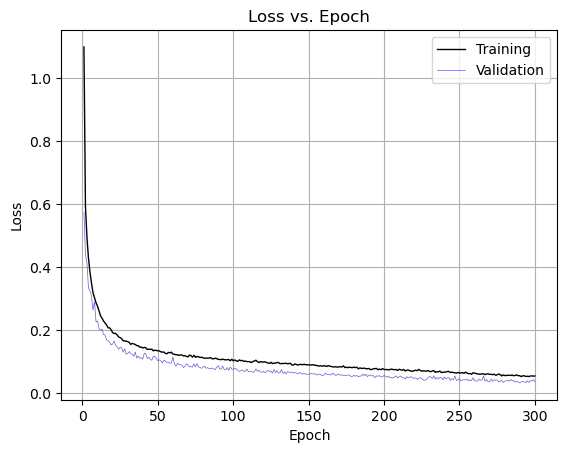

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import date, datetime

today_date = date.today()
print(f"Today's date: {today_date}")


input_size    = 75
hidden_layers = [256, 128,64]
output_size   = 4
dropout_probs = [0.3, 0.3, 0.3]
lr            = 1e-4
batch_size    = 256

print(input_size, hidden_layers, output_size, dropout_probs)

directory = 'Figures/['
for a in range(len(hidden_layers)):
    directory += str(hidden_layers[a]) + ','
    if a == len(hidden_layers) - 1:
        directory = directory[:-1]
        directory += ']'
if not os.path.isdir(directory):
    os.makedirs(directory)
out = directory

metrics_file = directory + '/training_metrics.csv'
metrics      = pd.read_csv(metrics_file)

plt.plot(metrics['Epoch'], metrics['Train Loss'], label='Training',   color='black',     linewidth=1.0)
plt.plot(metrics['Epoch'], metrics['Val Loss'],   label='Validation', color='slateblue', linewidth=0.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Loss vs. Epoch')
plt.legend()
plt.grid(True)
plt.savefig(directory + '/loss_vs_epoch.png', dpi=300)
plt.show()


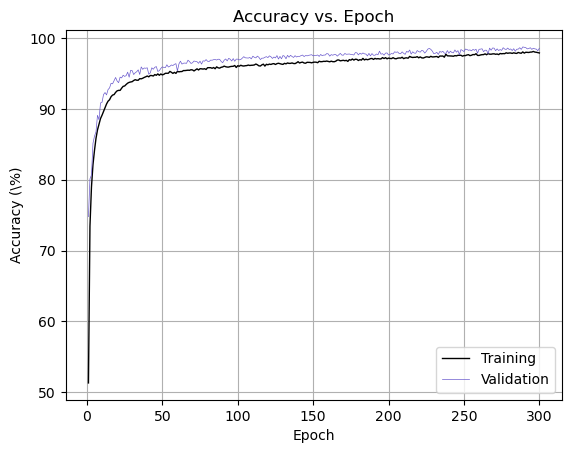

In [3]:
# Plot Accuracy vs. Epoch

max_train_accuracy = metrics["Train Accuracy"].max()
plt.plot(metrics["Epoch"], metrics["Train Accuracy"], label="Training", color="black", linewidth = 1.0)
plt.plot(metrics["Epoch"], metrics["Val Accuracy"], label="Validation", color="slateblue", linewidth = 0.5)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (\%)")
plt.title("Accuracy vs. Epoch")
plt.legend()
plt.grid(True)  # Add grid lines
plt.savefig(directory+"/accuracy_vs_Epoch.png", dpi=300)

### Training Monitoring and Confusion Check

75 [256, 128, 64] 4 [0.3, 0.3, 0.3]
File written successfully!
Loading checkpoint from: Figures/[256,128,64]/checkpoints\best_model.pth
Val samples: 8000


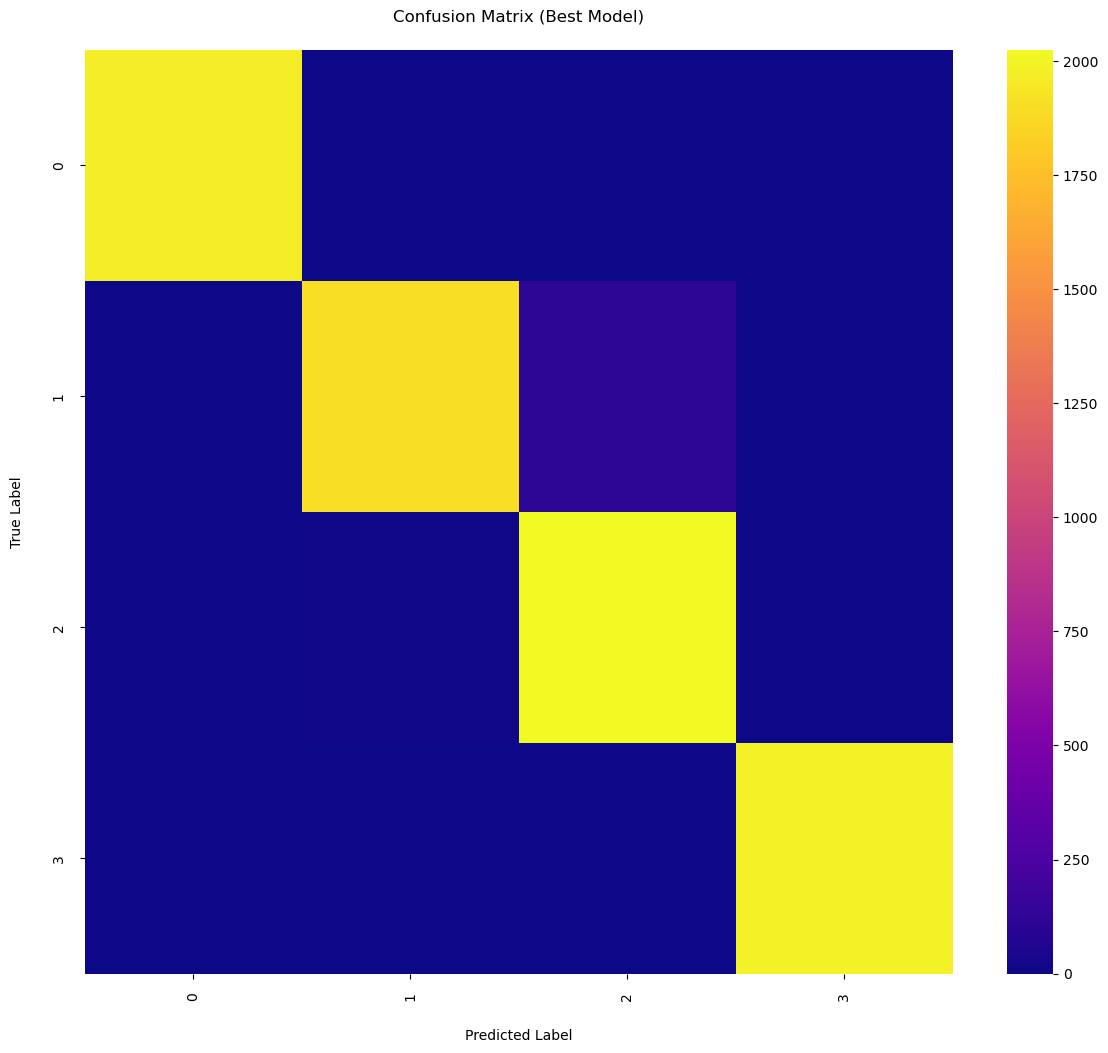

In [4]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix

import import_ipynb
import PTorchTraining
from PTorchTraining import CustomDataset, SimpleDNN

checkpoints_dir = directory + '/checkpoints'
checkpoint_path = os.path.join(checkpoints_dir, 'best_model.pth')

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint '{checkpoint_path}' does not exist.")
print(f"Loading checkpoint from: {checkpoint_path}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = SimpleDNN()
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
model.to(device)

with open(directory + '/val_loader.pkl', 'rb') as f:
    val_loader = pickle.load(f)

all_preds  = []
all_labels = []

with torch.no_grad():
    for data, labels in val_loader:
        data, labels = data.to(device), labels.to(device)
        outputs      = model(data)
        _, preds     = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Val samples: {len(all_preds)}")

cm           = confusion_matrix(all_labels, all_preds)
class_labels = [str(n) for n in range(output_size)]

plt.figure(figsize=(14, 12))
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='plasma',
                 xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix (Best Model)', pad=20)
plt.xlabel('Predicted Label', labelpad=20)
plt.ylabel('True Label',      labelpad=20)
ax.tick_params(axis='x', which='major', pad=10)
ax.tick_params(axis='y', which='major', pad=10)
plt.xticks(rotation=90)
plt.savefig(directory + '/4x4_Confusion_Matrix.png', dpi=500, bbox_inches='tight')
plt.show()


### Inference Stage

Interpret experimental data.

Loading checkpoint from: Figures/[256,128,64]/checkpoints\best_model.pth


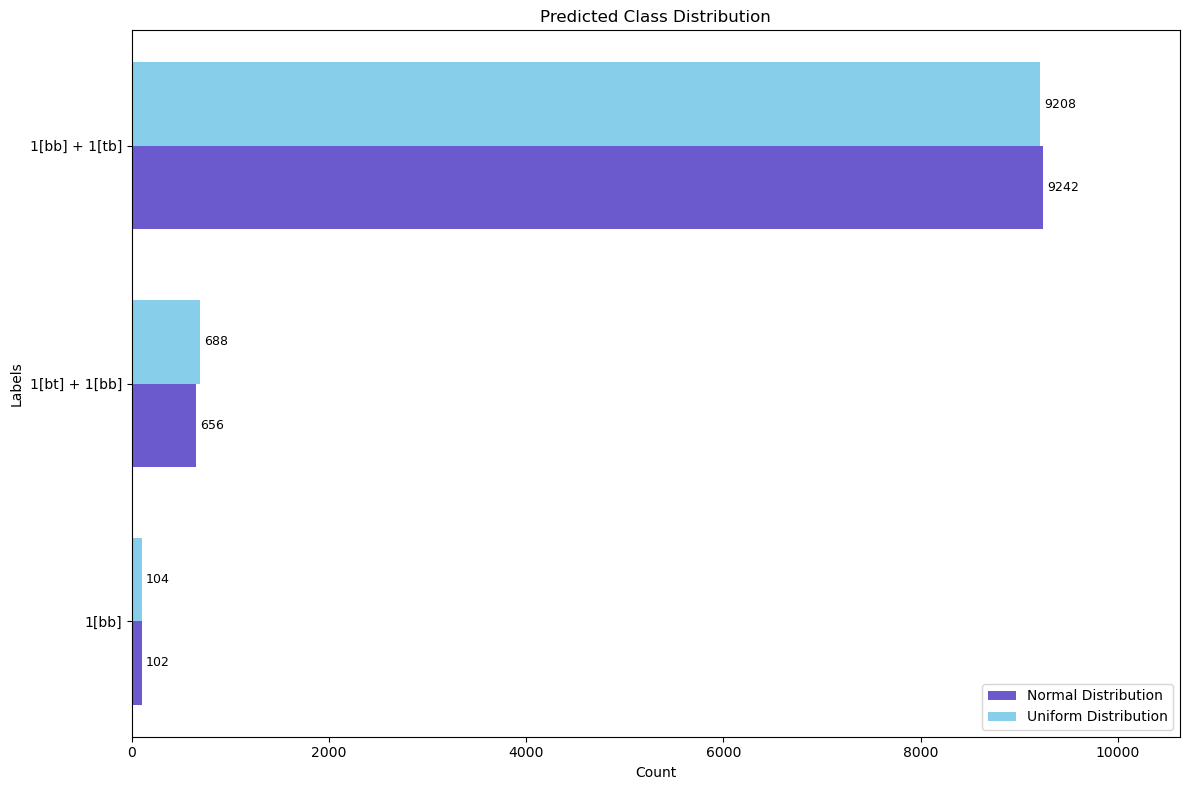


=== Confidence Summary ===

Normal distribution:
  Mean confidence          : 0.9928
  High-conf (>=80%) samples : 9865 / 10000
  Dominant class           : 3 (1[bb] + 1[tb]) - 9186 samples

Uniform distribution:
  Mean confidence          : 0.9923
  High-conf (>=80%) samples : 9853 / 10000
  Dominant class           : 3 (1[bb] + 1[tb]) - 9158 samples


In [5]:
import os
import random
import numpy as np
import torch
from collections import Counter
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

import import_ipynb
import PTorchTraining
from PTorchTraining import CustomDataset, SimpleDNN

# -------------------------------------------------------------------
# (A) LHCb Data Loading
# -------------------------------------------------------------------
LHCb_data           = np.loadtxt('Zc3900_D0Dbarstar.csv', skiprows=1, delimiter=',')
invmass             = LHCb_data[:, 0]
invmass_low         = LHCb_data[:, 4]
invmass_high        = LHCb_data[:, 5]
weighted_candidates = LHCb_data[:, 1]
upper_err           = np.abs(LHCb_data[:, 2])
lower_err           = np.abs(LHCb_data[:, 2])

energy_low  = invmass_low
energy_high = invmass_high

# -------------------------------------------------------------------
# (B) Generation Functions
# -------------------------------------------------------------------
def gen_Eaxis():
    return np.array([random.uniform(invmass_low[i], invmass_high[i])
                     for i in range(len(invmass))])

def gen_Amp_unif():
    return np.array([np.random.uniform(weighted_candidates[i] - upper_err[i],
                                       weighted_candidates[i] + upper_err[i])
                     for i in range(len(weighted_candidates))])

def gen_Amp_norm():
    return np.array([np.random.normal(weighted_candidates[i], upper_err[i] / 3)
                     for i in range(len(weighted_candidates))])

def zscore(arr):
    """Per-sample z-score — matches CustomDataset exactly."""
    mean = arr.mean()
    std  = arr.std() + 1e-8
    return (arr - mean) / std

def gen_Exp(amp_func):
    """
    Matches CustomDataset.__getitem__() exactly:
        Ch 0: z-scored intensity
        Ch 1: z-scored dI/dE
        Ch 2: z-scored d2I/dE2
        Ch 3: z-scored SG smoothed
        Shape: (4, N)
    """
    energy    = gen_Eaxis()
    intensity = amp_func()

    mask      = (energy < energy_high) & (energy >= energy_low)
    energy    = energy[mask].astype(np.float32)
    intensity = intensity[mask].astype(np.float32)

    d1       = np.gradient(intensity, energy).astype(np.float32)
    d2       = np.gradient(d1,        energy).astype(np.float32)
    smoothed = savgol_filter(intensity, window_length=4, polyorder=3).astype(np.float32)

    return torch.tensor(
        np.stack([
            zscore(intensity),
            zscore(d1),
            zscore(d2),
            zscore(smoothed),
        ], axis=0),
        dtype=torch.float32
    )

# -------------------------------------------------------------------
# (C) Generate Experimental Samples
# -------------------------------------------------------------------
num_samples   = 10000
Exp_data_norm = [gen_Exp(gen_Amp_norm) for _ in range(num_samples)]
Exp_data_unif = [gen_Exp(gen_Amp_unif) for _ in range(num_samples)]

# -------------------------------------------------------------------
# (D) Load Model
# -------------------------------------------------------------------
checkpoints_dir = directory + '/checkpoints'
checkpoint_path = os.path.join(checkpoints_dir, 'best_model.pth')

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint '{checkpoint_path}' does not exist.")
print(f"Loading checkpoint from: {checkpoint_path}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = SimpleDNN()
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
model.to(device)

# -------------------------------------------------------------------
# (E) Batched Inference with Confidence
# -------------------------------------------------------------------
def get_predictions_with_confidence(exp_data, model, device, batch_size=512):
    all_preds = []
    all_confs = []
    all_probs = []

    with torch.no_grad():
        for i in range(0, len(exp_data), batch_size):
            batch      = torch.stack(exp_data[i:i+batch_size], dim=0).to(device)
            logits     = model(batch)
            probs      = torch.softmax(logits, dim=1)
            conf, pred = torch.max(probs, dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_confs.extend(conf.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_confs), np.array(all_probs)

preds_norm, confs_norm, probs_norm = get_predictions_with_confidence(Exp_data_norm, model, device)
preds_unif, confs_unif, probs_unif = get_predictions_with_confidence(Exp_data_unif, model, device)

counts_norm = Counter(preds_norm)
counts_unif = Counter(preds_unif)

# -------------------------------------------------------------------
# (F) Class Labels (4 classes)
# -------------------------------------------------------------------
labels = [
    "no pole",
    "1[bb]",
    "1[bt] + 1[bb]",
    "1[bb] + 1[tb]"
    ]

valid_indices           = [i for i in range(output_size)
                           if counts_norm.get(i, 0) != 0 or counts_unif.get(i, 0) != 0]
custom_labels_remaining = [labels[i] for i in valid_indices]
values_norm             = [counts_norm.get(i, 0) for i in valid_indices]
values_unif             = [counts_unif.get(i, 0) for i in valid_indices]

# -------------------------------------------------------------------
# (G) Plot — Predicted Class Distribution
# -------------------------------------------------------------------
fig, ax    = plt.subplots(figsize=(12, 8))
bar_height = 0.35
br1        = np.arange(len(custom_labels_remaining))
br2        = br1 + bar_height

rects1 = ax.barh(br1, values_norm, height=bar_height, color='slateblue', label='Normal Distribution')
rects2 = ax.barh(br2, values_unif, height=bar_height, color='skyblue',   label='Uniform Distribution')

ax.bar_label(rects1, padding=3, fontsize=9)
ax.bar_label(rects2, padding=3, fontsize=9)
ax.set_ylabel('Labels')
ax.set_xlabel('Count')
ax.set_title('Predicted Class Distribution')
ax.set_xlim(0, max(max(values_norm), max(values_unif)) * 1.15)
ax.set_yticks(br1 + bar_height / 2)
ax.set_yticklabels(custom_labels_remaining)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(directory, 'Classification_Horizontal.png'), dpi=300)
plt.show()

# -------------------------------------------------------------------
# (H) Confidence Summary
# -------------------------------------------------------------------
CONFIDENCE_THRESHOLD = 0.80
print('\n=== Confidence Summary ===')
for label_str, preds, confs in [('Normal',  preds_norm, confs_norm),
                                  ('Uniform', preds_unif, confs_unif)]:
    high_mask = confs >= CONFIDENCE_THRESHOLD
    dominant  = Counter(preds[high_mask]).most_common(1)
    dom_class = dominant[0][0] if dominant else -1
    dom_count = dominant[0][1] if dominant else 0
    print(f'\n{label_str} distribution:')
    print(f'  Mean confidence          : {confs.mean():.4f}')
    print(f'  High-conf (>={CONFIDENCE_THRESHOLD:.0%}) samples : {high_mask.sum()} / {len(preds)}')
    if dom_class >= 0:
        print(f'  Dominant class           : {dom_class} ({labels[dom_class]}) - {dom_count} samples')


In [6]:
from sklearn.metrics import classification_report

labels = [
    "no pole",
    "1[bb]",
    "1[bt] + 1[bb]",
    "1[bb] + 1[tb]"
    ]

report = classification_report(all_labels, all_preds, target_names=labels)
print(report)

file_path = directory + '/classification_report.txt'
with open(file_path, 'w') as f:
    f.write(report)
print(f'Classification report saved to {file_path}')


               precision    recall  f1-score   support

      no pole       1.00      1.00      1.00      1968
        1[bb]       1.00      0.95      0.97      2005
1[bt] + 1[bb]       0.95      1.00      0.97      2034
1[bb] + 1[tb]       1.00      1.00      1.00      1993

     accuracy                           0.99      8000
    macro avg       0.99      0.99      0.99      8000
 weighted avg       0.99      0.99      0.99      8000

Classification report saved to Figures/[256,128,64]/classification_report.txt


In [7]:
from datetime import date, datetime

# Get the current date
today_date = date.today()
print(f"Today's date: {today_date}")


Today's date: 2026-05-26
